# Weather Data Preprocessing for the Philippines

This notebook demonstrates how to clean, preprocess, and prepare a weather dataset for machine learning tasks. The dataset contains weather records for the Philippines, organized by country, province, and municipality. We will cover data cleaning, feature engineering, visualization, and preparation for ML models such as classification, regression, and LSTM forecasting.

## 1. Import Libraries and Set Up

We will import essential libraries for data manipulation, visualization, and machine learning preprocessing.

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Set plot styles
plt.style.use('seaborn-v0_8')
sns.set_palette('Blues')

## 2. Load Raw Weather Dataset

Load the raw weather data from 'philippines_weather_raw.csv' and display the first few rows to understand its structure.

In [4]:
# Load the raw weather dataset
raw_df = pd.read_csv('philippines_weather_raw.csv')
print('Shape:', raw_df.shape)
raw_df.head()

Shape: (100000, 10)


,date,country,province,municipality,temperature,humidity,rainfall,wind_speed,pressure,weather_condition
0,2024-11-05,Philippines,Pangasinan,Urdaneta,26.1,81,13.3,8.1,1018,Sunny
1,2024-07-22,Philippines,Oriental Mindoro,Pinamalayan,27.1,84,0.2,9.5,1005,Sunny
2,2024-11-24,Philippines,Pangasinan,San Carlos,27.0,68,3.6,17.7,1008,Sunny
3,2024-10-26,Philippines,Negros Occidental,Bacolod,27.4,89,10.0,16.9,1017,Cloudy
4,2024-07-19,Philippines,Oriental Mindoro,Calapan,28.1,71,11.6,8.7,1016,Cloudy


## 3. Data Cleaning

We will clean the dataset by handling missing values, filling missing weather conditions, and removing duplicates.

In [5]:
# Fill missing numeric values using interpolation
numeric_cols = ['temperature', 'humidity', 'rainfall', 'wind_speed', 'pressure']
clean_df = raw_df.copy()
clean_df[numeric_cols] = clean_df[numeric_cols].interpolate(method='linear', limit_direction='both')

# Fill missing weather_condition with the most frequent value
most_freq_condition = clean_df['weather_condition'].mode()[0]
clean_df['weather_condition'] = clean_df['weather_condition'].fillna(most_freq_condition)

# Remove duplicate rows
clean_df = clean_df.drop_duplicates()

# Check for remaining missing values
clean_df.isnull().sum()

date                 0
country              0
province             0
municipality         0
temperature          0
humidity             0
rainfall             0
wind_speed           0
pressure             0
weather_condition    0
dtype: int64

## 4. Feature Engineering

We will extract new features, encode categorical variables, and normalize numeric columns for machine learning.

In [6]:
# Convert date to datetime and extract year, month, day
clean_df['date'] = pd.to_datetime(clean_df['date'])
clean_df['year'] = clean_df['date'].dt.year
clean_df['month'] = clean_df['date'].dt.month
clean_df['day'] = clean_df['date'].dt.day

# Add seasonal features (simple rules for PH)
def get_season(month):
    if month in [3, 4, 5]:
        return 'summer'
    elif month in [6, 7, 8, 9, 10, 11]:
        return 'rainy'
    else:
        return 'dry'
clean_df['season'] = clean_df['month'].apply(get_season)

# Encode weather_condition
le = LabelEncoder()
clean_df['weather_condition_encoded'] = le.fit_transform(clean_df['weather_condition'])

# Normalize numeric features
scaler = MinMaxScaler()
clean_df[numeric_cols] = scaler.fit_transform(clean_df[numeric_cols])

clean_df.head()

,date,country,province,municipality,temperature,humidity,rainfall,wind_speed,pressure,weather_condition,year,month,day,season,weather_condition_encoded
0,2024-11-05,Philippines,Pangasinan,Urdaneta,0.262626,0.525,0.665,0.338889,0.72,Sunny,2024,11,5,rainy,2
1,2024-07-22,Philippines,Oriental Mindoro,Pinamalayan,0.363636,0.600,0.010,0.416667,0.20,Sunny,2024,7,22,rainy,2
2,2024-11-24,Philippines,Pangasinan,San Carlos,0.353535,0.200,0.180,0.872222,0.32,Sunny,2024,11,24,rainy,2
3,2024-10-26,Philippines,Negros Occidental,Bacolod,0.393939,0.725,0.500,0.827778,0.68,Cloudy,2024,10,26,rainy,0
4,2024-07-19,Philippines,Oriental Mindoro,Calapan,0.464646,0.275,0.580,0.372222,0.64,Cloudy,2024,7,19,rainy,0


## 5. Split Data by Province and Municipality

We can group or split the cleaned data by province and municipality for further analysis or modeling.

In [7]:
# Example: Group by province and municipality
province_groups = clean_df.groupby('province')
municipality_groups = clean_df.groupby(['province', 'municipality'])

# Display the number of records per province
province_counts = province_groups.size().sort_values(ascending=False)
province_counts

province
Negros Occidental    20204
Oriental Mindoro     19990
Pangasinan           19948
Cebu                 19946
Davao del Sur        19912
dtype: int64

## 6. Save Cleaned Dataset

Save the cleaned and processed dataset to 'philippines_weather_clean.csv' for future use.

In [8]:
# Save cleaned dataset
clean_df.to_csv('philippines_weather_clean.csv', index=False)
print('Cleaned dataset saved as philippines_weather_clean.csv')

Cleaned dataset saved as philippines_weather_clean.csv


## 7. Summary Statistics and Visualizations

Let's explore the cleaned data with summary statistics and visualizations: temperature trends, rainfall trends, missing value heatmap, and correlation matrix.

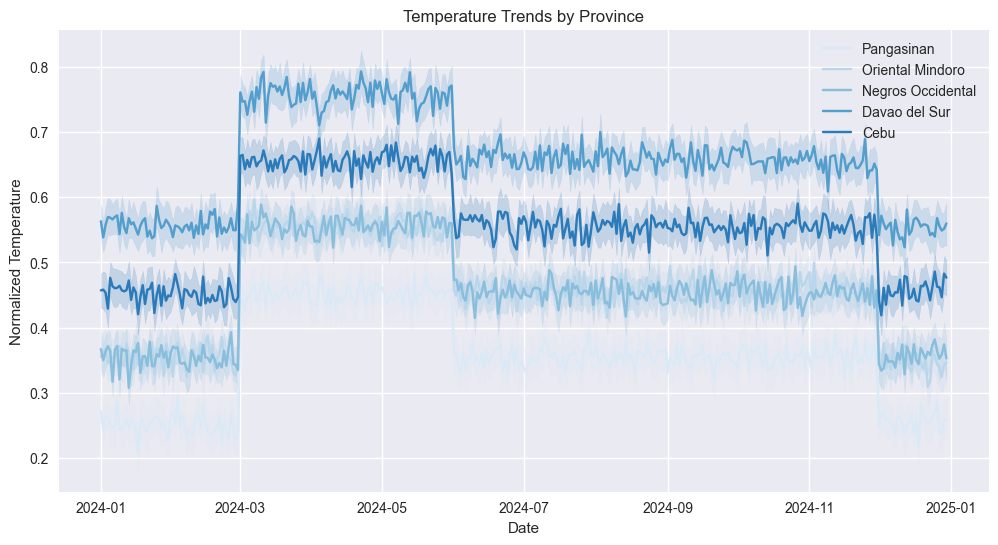

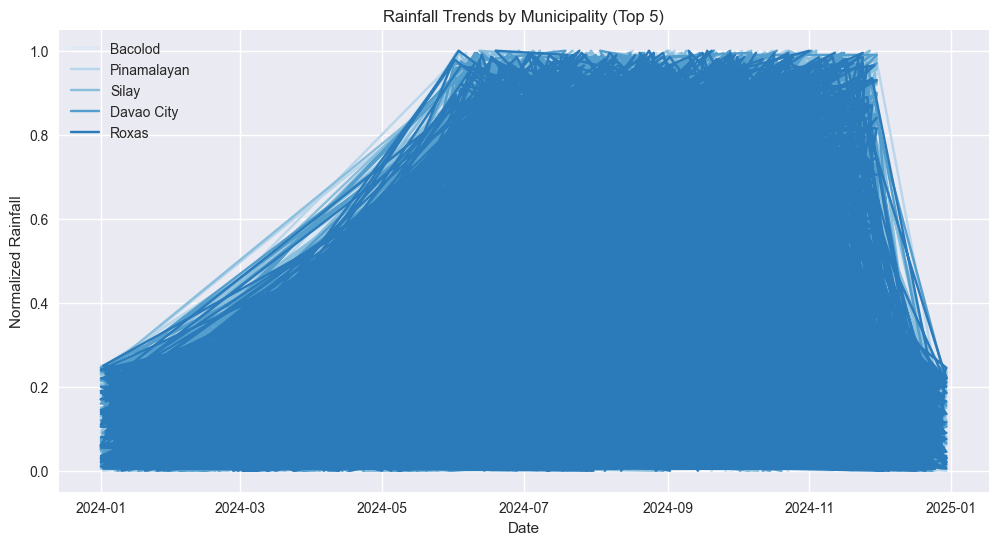

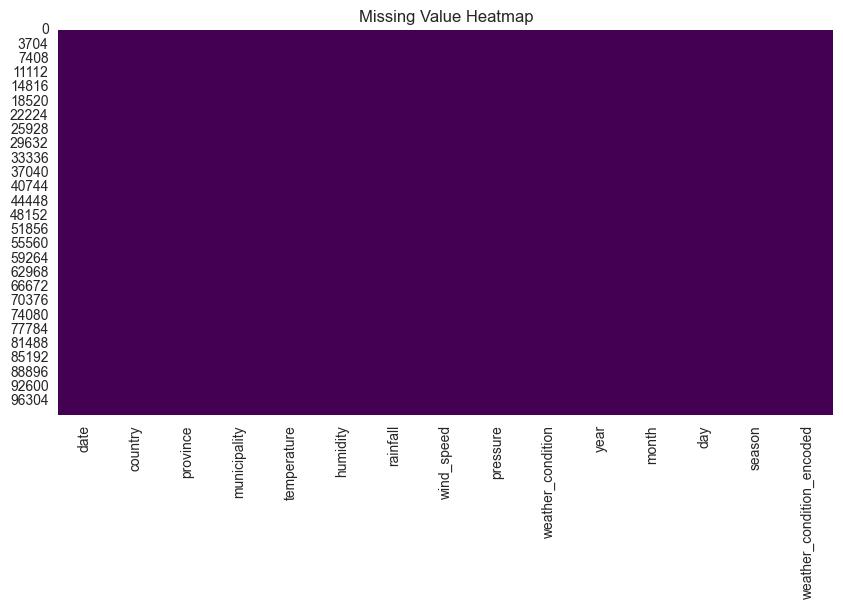

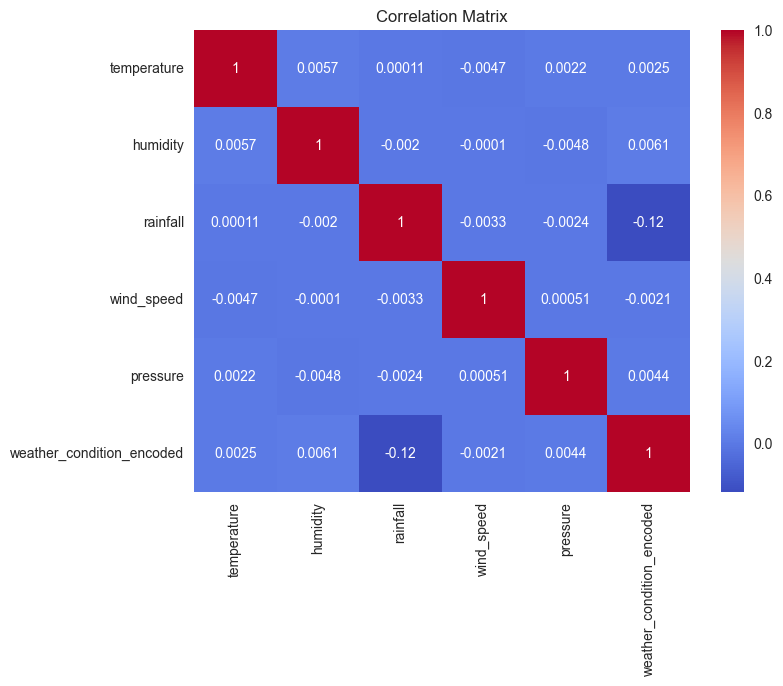

In [9]:
# Temperature trends by province
plt.figure(figsize=(12,6))
sns.lineplot(data=clean_df, x='date', y='temperature', hue='province')
plt.title('Temperature Trends by Province')
plt.ylabel('Normalized Temperature')
plt.xlabel('Date')
plt.legend(loc='upper right')
plt.show()

# Rainfall trends by municipality (top 5 municipalities)
top_munis = clean_df['municipality'].value_counts().head(5).index
plt.figure(figsize=(12,6))
for muni in top_munis:
    muni_df = clean_df[clean_df['municipality'] == muni]
    plt.plot(muni_df['date'], muni_df['rainfall'], label=muni)
plt.title('Rainfall Trends by Municipality (Top 5)')
plt.ylabel('Normalized Rainfall')
plt.xlabel('Date')
plt.legend()
plt.show()

# Missing value heatmap
plt.figure(figsize=(10,5))
sns.heatmap(clean_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show()

# Correlation matrix
plt.figure(figsize=(8,6))
corr = clean_df[numeric_cols + ['weather_condition_encoded']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 8. Prepare Dataset for Machine Learning Tasks

We will prepare the final dataset for three ML tasks:
- Current weather classification
- Tomorrow's weather regression
- 7-day LSTM forecasting (sequence generation)

Each task requires specific preprocessing and target variable selection.

In [10]:
# 1. Current weather classification (features and target)
classification_features = ['temperature', 'humidity', 'rainfall', 'wind_speed', 'pressure', 'month', 'day', 'season']
X_class = clean_df[classification_features]
y_class = clean_df['weather_condition_encoded']

# 2. Tomorrow's weather regression (shift target by 1 day per location)
clean_df_sorted = clean_df.sort_values(['province', 'municipality', 'date'])
clean_df_sorted['tomorrow_temperature'] = clean_df_sorted.groupby(['province', 'municipality'])['temperature'].shift(-1)
regression_features = ['temperature', 'humidity', 'rainfall', 'wind_speed', 'pressure', 'month', 'day', 'season']
X_reg = clean_df_sorted[regression_features].dropna()
y_reg = clean_df_sorted['tomorrow_temperature'].dropna()

# 3. 7-day LSTM forecasting (sequence generation)
from sklearn.preprocessing import OneHotEncoder
seq_features = ['temperature', 'humidity', 'rainfall', 'wind_speed', 'pressure']
sequences = []
seq_length = 7
for _, group in clean_df_sorted.groupby(['province', 'municipality']):
    vals = group[seq_features].values
    for i in range(len(vals) - seq_length):
        sequences.append(vals[i:i+seq_length])
sequences = np.array(sequences)
print(f"Generated {sequences.shape[0]} sequences for LSTM forecasting.")

Generated 99895 sequences for LSTM forecasting.
